# Experiment 1 Results — Master Core Ablation
Shared neurons (MMLU_K ∩ ASDiv ∩ Orig) ablated across K thresholds.
Datasets: ASDiv, Origin, MMLU (7 subjects so far).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from glob import glob

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

RESULTS_BASE  = 'results_exp1'
REWARD_POINTS = [10, 20, 30, 40]
K_THRESHOLDS  = [27, 30, 35, 40, 45, 50, 54]

# Neuron counts per tier
NEURON_COUNTS = {
    'baseline':   0,
    'model_A':    1363,
    'master_k27': 304,
    'master_k30': 287,
    'master_k35': 263,
    'master_k40': 233,
    'master_k45': 181,
    'master_k50': 107,
    'master_k54': 29,
}

ALL_TIERS = ['baseline', 'model_A'] + [f'master_k{k}' for k in K_THRESHOLDS]

# Colors
TIER_COLORS = {
    'baseline':   '#888888',
    'model_A':    '#D65F5F',
}
CMAP = plt.cm.Blues
for i, k in enumerate(K_THRESHOLDS):
    TIER_COLORS[f'master_k{k}'] = CMAP(0.4 + 0.08*i)

print('Config ready.')

Config ready.


In [2]:
# Load all available results
asdiv_sum  = pd.read_csv(f'{RESULTS_BASE}/asdiv/summary.csv')
origin_sum = pd.read_csv(f'{RESULTS_BASE}/origin/summary.csv')
asdiv_run  = pd.read_csv(f'{RESULTS_BASE}/asdiv/run_stats.csv')
origin_run = pd.read_csv(f'{RESULTS_BASE}/origin/run_stats.csv')
asdiv_sub  = pd.read_csv(f'{RESULTS_BASE}/asdiv/subset_stats.csv')
origin_sub = pd.read_csv(f'{RESULTS_BASE}/origin/subset_stats.csv')

# Load MMLU subjects
mmlu_frames = []
for path in sorted(glob(f'{RESULTS_BASE}/mmlu/*/summary.csv')):
    subject = path.split('/')[-2]
    df = pd.read_csv(path)
    df['subject'] = subject
    mmlu_frames.append(df)
mmlu_all = pd.concat(mmlu_frames, ignore_index=True) if mmlu_frames else pd.DataFrame()

# Load MMLU run stats
mmlu_run_frames = []
for path in sorted(glob(f'{RESULTS_BASE}/mmlu/*/run_stats.csv')):
    subject = path.split('/')[-2]
    df = pd.read_csv(path)
    df['subject'] = subject
    mmlu_run_frames.append(df)
mmlu_runs = pd.concat(mmlu_run_frames, ignore_index=True) if mmlu_run_frames else pd.DataFrame()

print(f'ASDiv:  {len(asdiv_sum)} tiers')
print(f'Origin: {len(origin_sum)} tiers')
print(f'MMLU:   {len(mmlu_frames)} subjects')
if mmlu_frames:
    print(f'  {[p.split("/")[-2] for p in sorted(glob(f"{RESULTS_BASE}/mmlu/*/summary.csv"))]}')

ASDiv:  9 tiers
Origin: 9 tiers
MMLU:   6 subjects
  ['college_mathematics', 'college_physics', 'econometrics', 'formal_logic', 'high_school_european_history', 'high_school_mathematics']


## 1 — Mean attempted points across all tiers and datasets

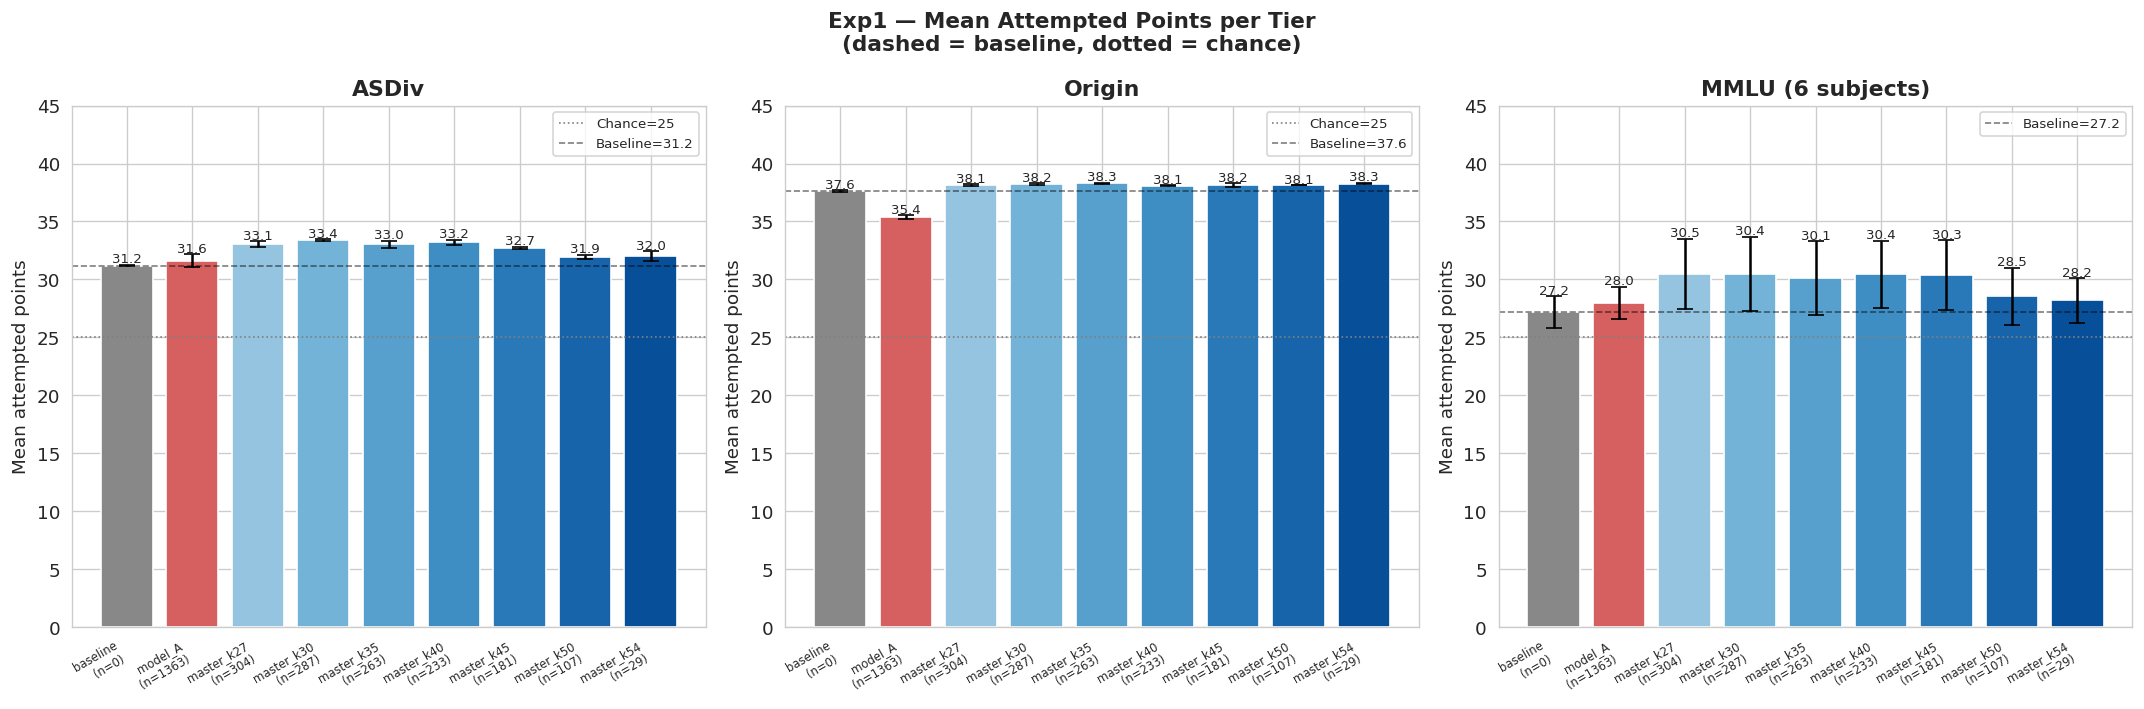

In [9]:
def get_run_stats(run_df, tier):
    td = run_df[run_df['tier'] == tier]['mean_att_pts']
    return td.mean(), td.std()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, sum_df, run_df) in zip(axes[:2], [
    ('ASDiv',  asdiv_sum,  asdiv_run),
    ('Origin', origin_sum, origin_run),
]):
    tiers_avail = [t for t in ALL_TIERS if t in sum_df['tier'].values]
    means, stds, colors, labels = [], [], [], []
    for tier in tiers_avail:
        m, s = get_run_stats(run_df, tier)
        means.append(m); stds.append(s)
        colors.append(TIER_COLORS[tier])
        n = NEURON_COUNTS.get(tier, 0)
        labels.append(f'{tier}\n(n={n})')
    x = np.arange(len(tiers_avail))
    bars = ax.bar(x, means, color=colors, yerr=stds, capsize=5, edgecolor='white')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x()+bar.get_width()/2, m+s+0.2,
                f'{m:.1f}', ha='center', fontsize=8)
    ax.axhline(25, color='gray', linestyle=':', linewidth=1, label='Chance=25')
    baseline_val = sum_df[sum_df['tier']=='baseline']['mean_att_pts'].values[0]
    ax.axhline(baseline_val, color='black', linestyle='--', linewidth=1,
               alpha=0.5, label=f'Baseline={baseline_val:.1f}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=30, ha='right')
    ax.set_ylabel('Mean attempted points')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 45)
    ax.legend(fontsize=8)

# MMLU
ax = axes[2]
if not mmlu_runs.empty:
    tiers_avail = [t for t in ALL_TIERS if t in mmlu_runs['tier'].values]
    means, stds, colors, labels = [], [], [], []
    for tier in tiers_avail:
        td = mmlu_runs[mmlu_runs['tier']==tier].groupby('subject')['mean_att_pts'].mean()
        means.append(td.mean()); stds.append(td.std())
        colors.append(TIER_COLORS[tier])
        n = NEURON_COUNTS.get(tier, 0)
        labels.append(f'{tier}\n(n={n})')
    x = np.arange(len(tiers_avail))
    bars = ax.bar(x, means, color=colors, yerr=stds, capsize=5, edgecolor='white')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x()+bar.get_width()/2, m+s+0.2,
                f'{m:.1f}', ha='center', fontsize=8)
    ax.axhline(25, color='gray', linestyle=':', linewidth=1)
    mmlu_baseline = mmlu_all[mmlu_all['tier']=='baseline']['mean_att_pts'].mean()
    ax.axhline(mmlu_baseline, color='black', linestyle='--', linewidth=1,
               alpha=0.5, label=f'Baseline={mmlu_baseline:.1f}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=30, ha='right')
    ax.set_ylim(0, 45)
    ax.legend(fontsize=8)

ax.set_ylabel('Mean attempted points')
ax.set_title(f'MMLU ({len(mmlu_frames)} subjects)', fontweight='bold')

fig.suptitle('Exp1 — Mean Attempted Points per Tier\n(dashed = baseline, dotted = chance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp1_mean_pts.png', bbox_inches='tight')
plt.show()

## 2 — Delta from baseline (Δ mean pts)

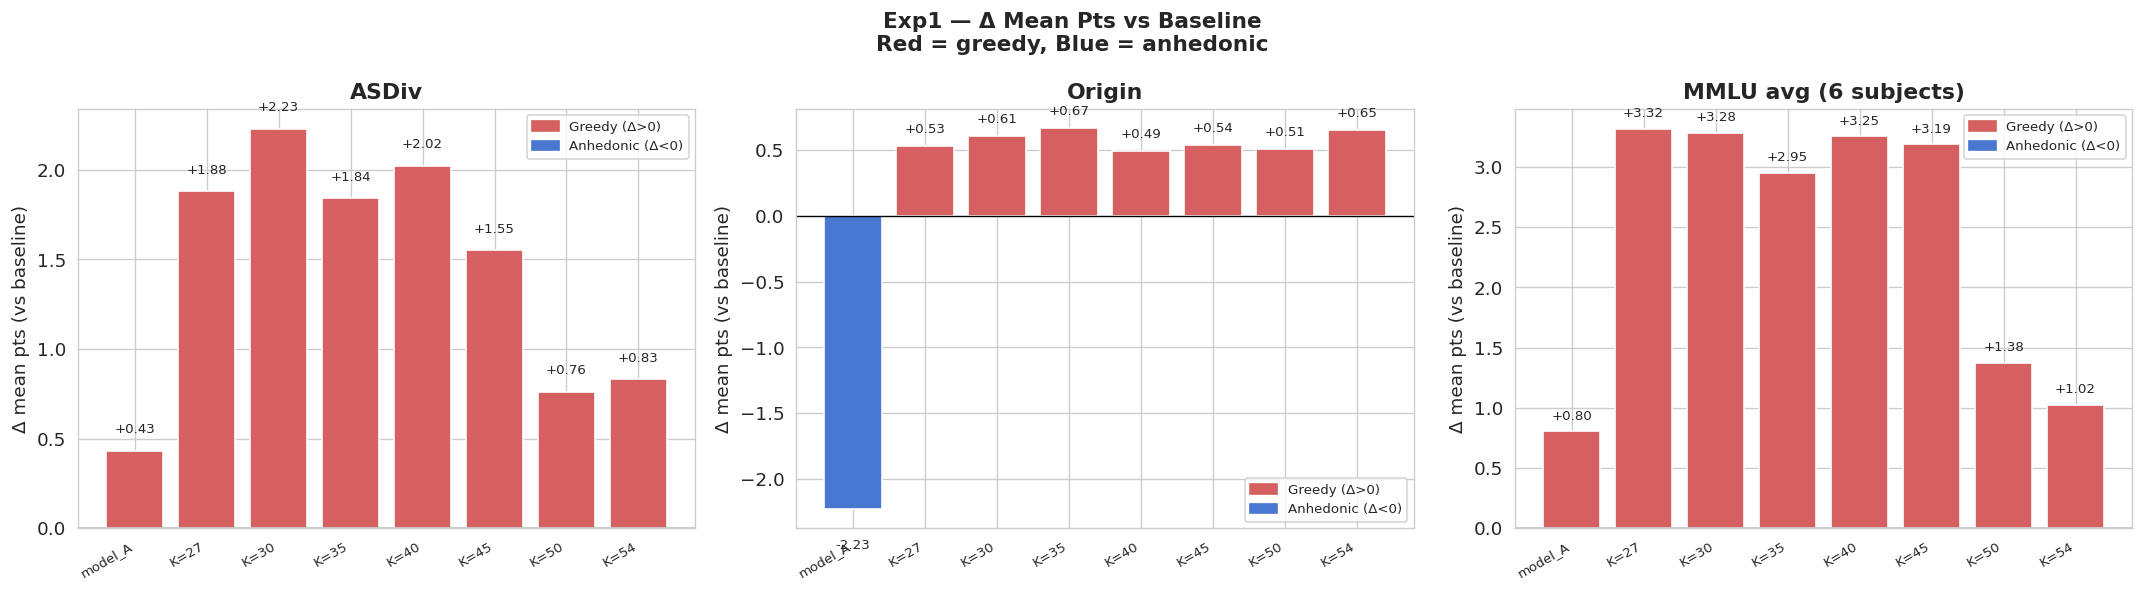

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, sum_df) in zip(axes[:2], [
    ('ASDiv',  asdiv_sum),
    ('Origin', origin_sum),
]):
    baseline_val = sum_df[sum_df['tier']=='baseline']['mean_att_pts'].values[0]
    tiers_plot   = [t for t in ALL_TIERS if t != 'baseline' and t in sum_df['tier'].values]
    deltas  = [sum_df[sum_df['tier']==t]['mean_att_pts'].values[0] - baseline_val
               for t in tiers_plot]
    colors  = ['#D65F5F' if d > 0 else '#4878CF' for d in deltas]
    x = np.arange(len(tiers_plot))
    bars = ax.bar(x, deltas, color=colors, edgecolor='white')
    for bar, d in zip(bars, deltas):
        ax.text(bar.get_x()+bar.get_width()/2,
                d + (0.1 if d >= 0 else -0.3),
                f'{d:+.2f}', ha='center', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace('master_k','K=') for t in tiers_plot],
                       fontsize=8, rotation=30, ha='right')
    ax.set_ylabel('Δ mean pts (vs baseline)')
    ax.set_title(title, fontweight='bold')
    red   = mpatches.Patch(color='#D65F5F', label='Greedy (Δ>0)')
    blue  = mpatches.Patch(color='#4878CF', label='Anhedonic (Δ<0)')
    ax.legend(handles=[red, blue], fontsize=8)

# MMLU delta
ax = axes[2]
if not mmlu_all.empty:
    mmlu_baseline = mmlu_all[mmlu_all['tier']=='baseline']['mean_att_pts'].mean()
    tiers_plot = [t for t in ALL_TIERS if t != 'baseline' and t in mmlu_all['tier'].values]
    deltas = [mmlu_all[mmlu_all['tier']==t]['mean_att_pts'].mean() - mmlu_baseline
              for t in tiers_plot]
    colors = ['#D65F5F' if d > 0 else '#4878CF' for d in deltas]
    x = np.arange(len(tiers_plot))
    bars = ax.bar(x, deltas, color=colors, edgecolor='white')
    for bar, d in zip(bars, deltas):
        ax.text(bar.get_x()+bar.get_width()/2,
                d + (0.1 if d >= 0 else -0.3),
                f'{d:+.2f}', ha='center', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace('master_k','K=') for t in tiers_plot],
                       fontsize=8, rotation=30, ha='right')
    ax.set_ylabel('Δ mean pts (vs baseline)')
    ax.legend(handles=[red, blue], fontsize=8)

ax.set_title(f'MMLU avg ({len(mmlu_frames)} subjects)', fontweight='bold')
fig.suptitle('Exp1 — Δ Mean Pts vs Baseline\nRed = greedy, Blue = anhedonic',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp1_delta.png', bbox_inches='tight')
plt.show()

## 3 — Point tier choice rates

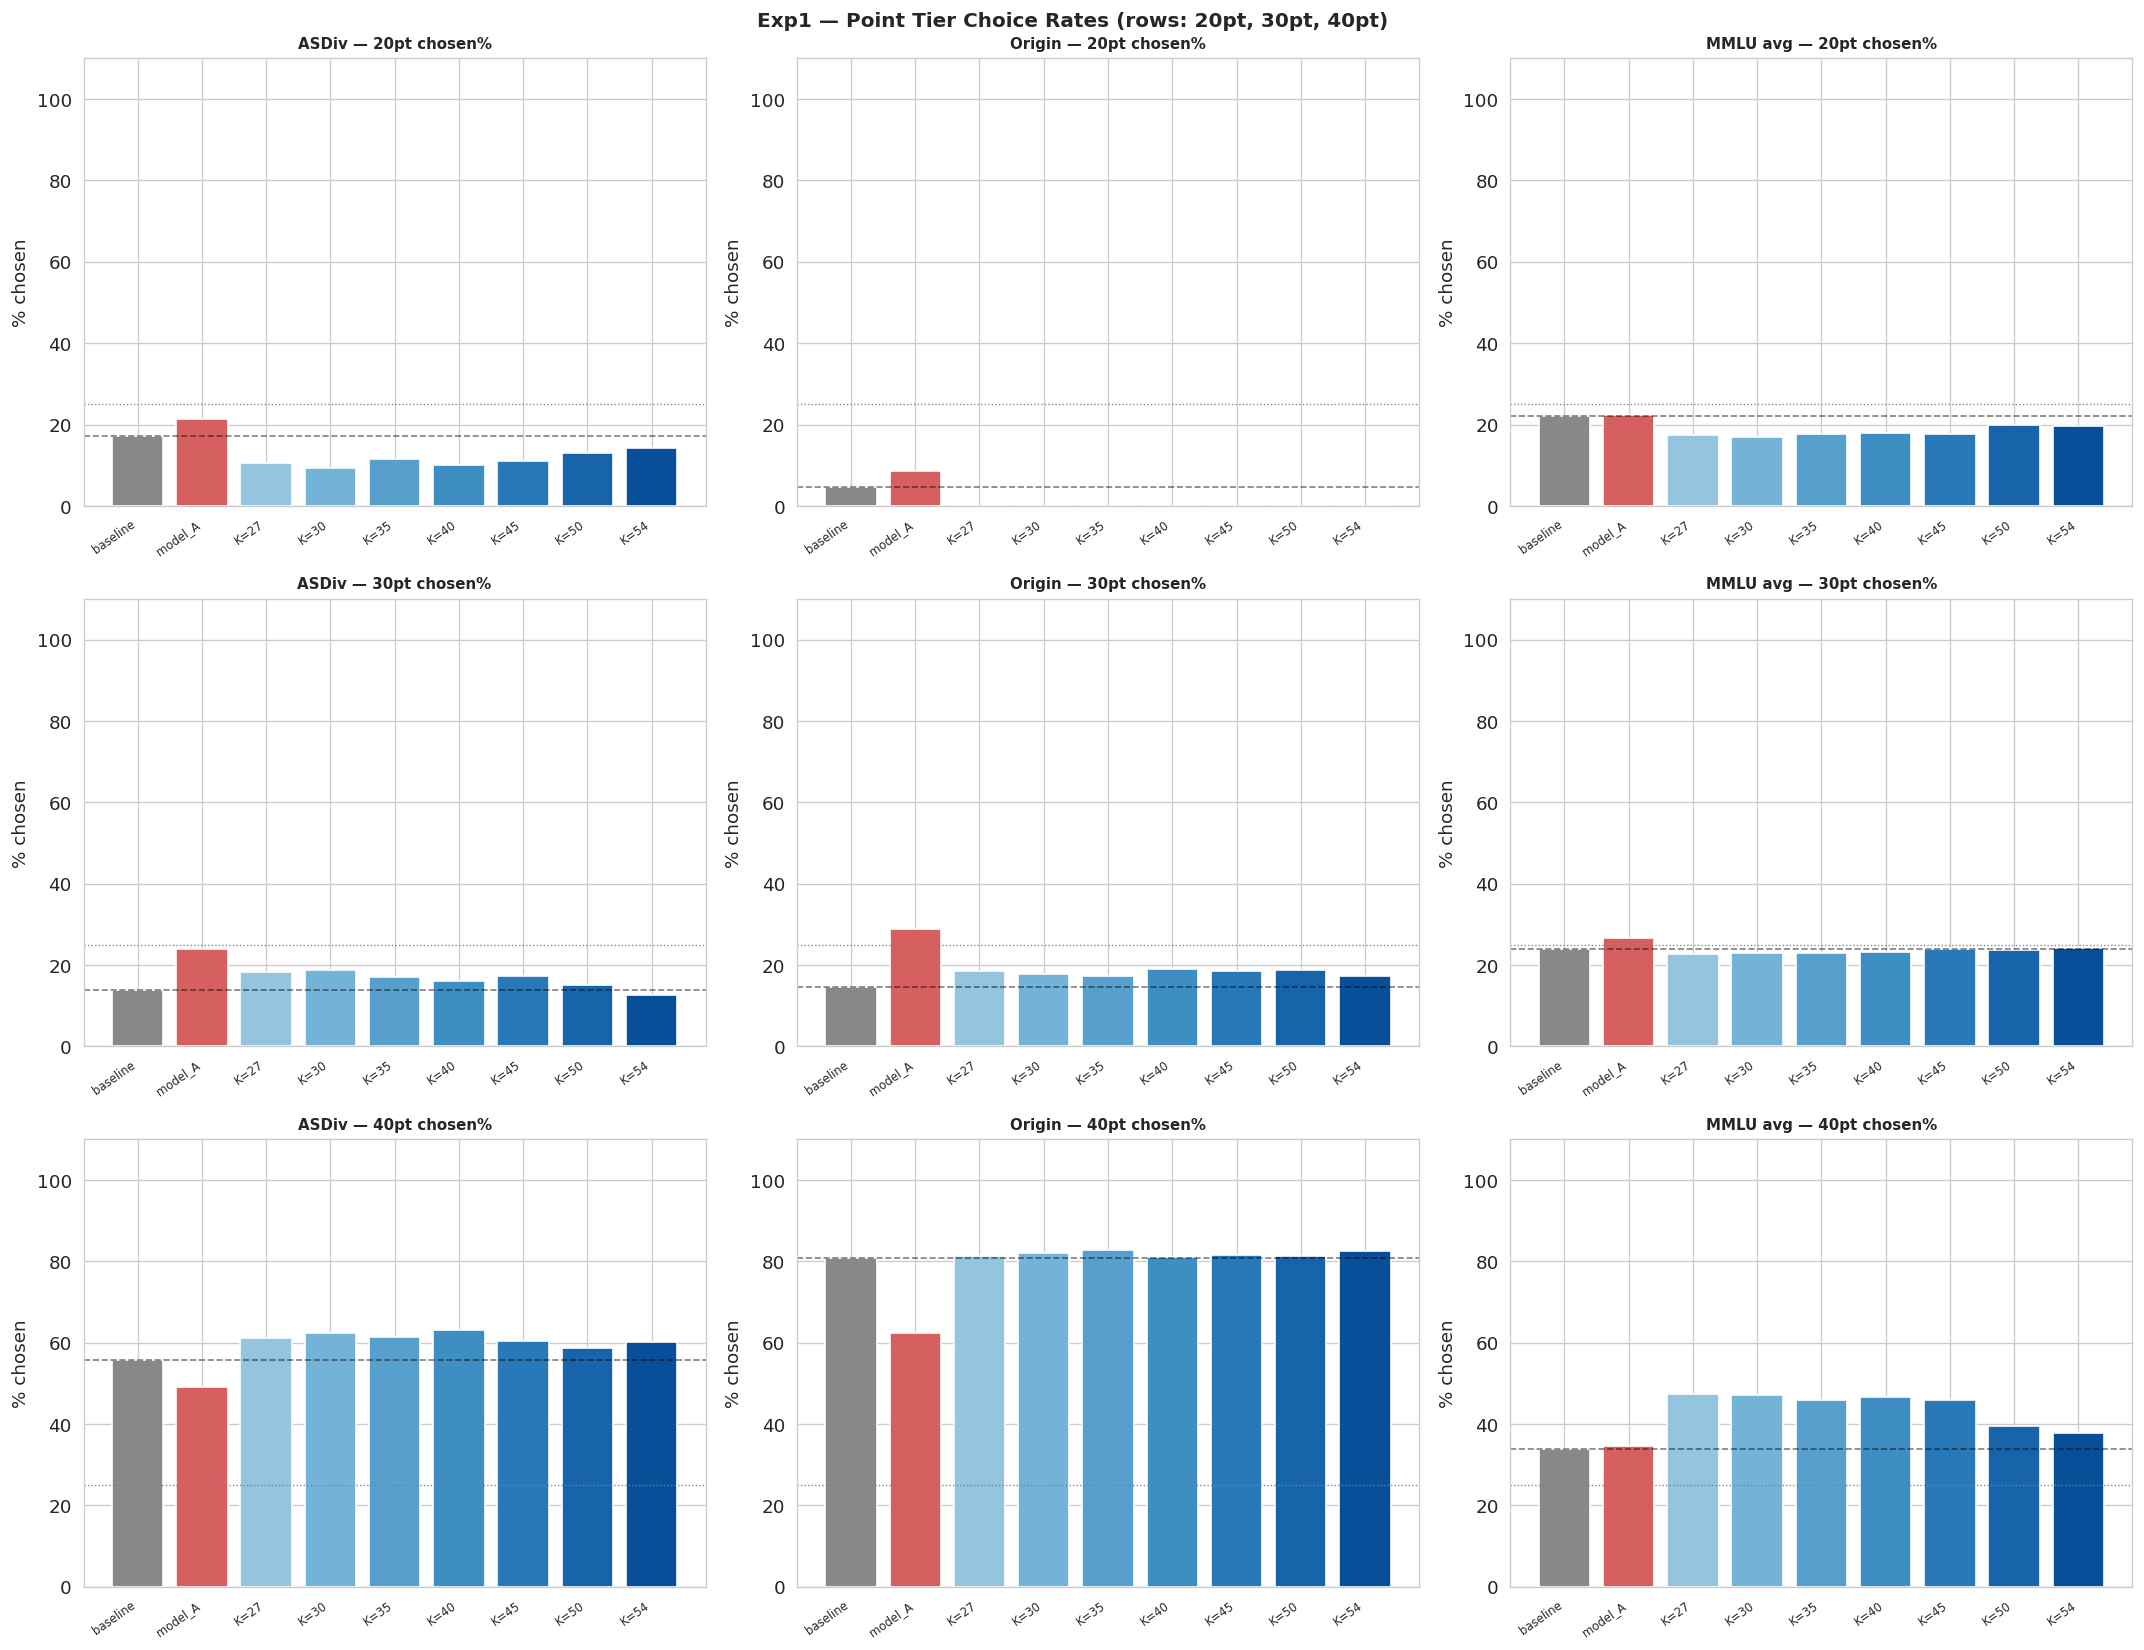

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

datasets = [('ASDiv', asdiv_sum), ('Origin', origin_sum)]
if not mmlu_all.empty:
    mmlu_avg = mmlu_all.groupby('tier').mean(numeric_only=True).reset_index()
    datasets.append((f'MMLU avg', mmlu_avg))

for col_idx, (ds_name, sum_df) in enumerate(datasets):
    for row_idx, pts in enumerate([20, 30, 40]):
        ax = axes[row_idx][col_idx]
        tiers_avail = [t for t in ALL_TIERS if t in sum_df['tier'].values]
        vals   = [sum_df[sum_df['tier']==t][f'{pts}pt_chosen_%'].values[0]
                  for t in tiers_avail]
        colors = [TIER_COLORS[t] for t in tiers_avail]
        x = np.arange(len(tiers_avail))
        ax.bar(x, vals, color=colors, edgecolor='white')
        ax.axhline(25, color='gray', linestyle=':', linewidth=0.8)
        baseline_val = sum_df[sum_df['tier']=='baseline'][f'{pts}pt_chosen_%'].values[0]
        ax.axhline(baseline_val, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([t.replace('master_k','K=') for t in tiers_avail],
                           fontsize=7, rotation=35, ha='right')
        ax.set_title(f'{ds_name} — {pts}pt chosen%', fontsize=9, fontweight='bold')
        ax.set_ylabel('% chosen')
        ax.set_ylim(0, 110)

fig.suptitle('Exp1 — Point Tier Choice Rates (rows: 20pt, 30pt, 40pt)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('exp1_choice_rates.png', bbox_inches='tight')
plt.show()

## 4 — Position-controlled: 40pt choice rate at each position

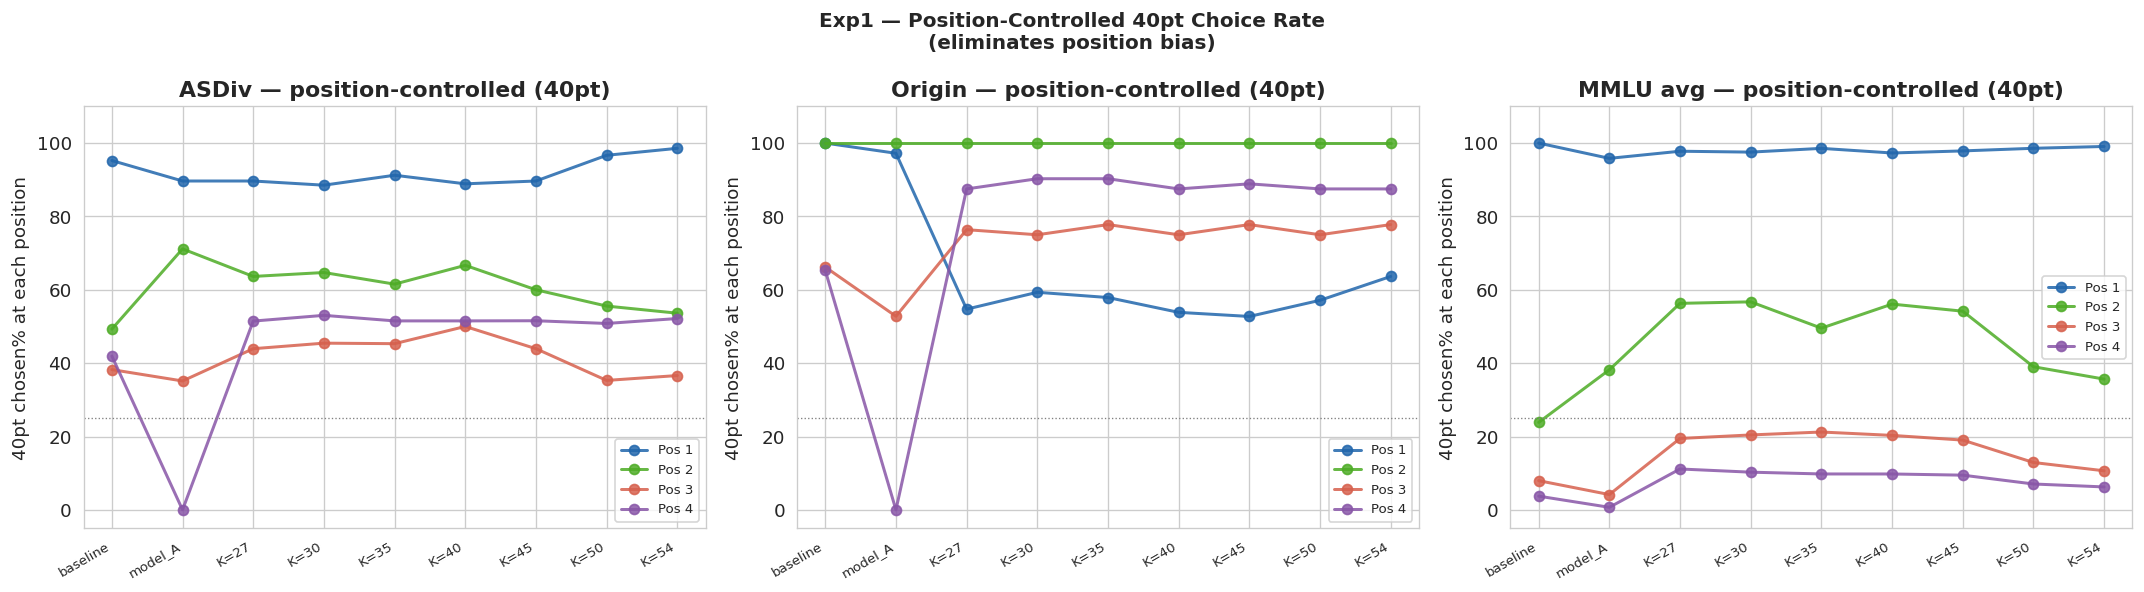

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [('ASDiv', asdiv_sum), ('Origin', origin_sum)]
if not mmlu_all.empty:
    mmlu_avg = mmlu_all.groupby('tier').mean(numeric_only=True).reset_index()
    datasets.append(('MMLU avg', mmlu_avg))

pos_colors = ['#2166AC','#4DAC26','#D6604D','#8856A7']

for ax, (ds_name, sum_df) in zip(axes, datasets):
    tiers_avail = [t for t in ALL_TIERS if t in sum_df['tier'].values]
    x = np.arange(len(tiers_avail))
    for pi, pos in enumerate([1,2,3,4]):
        col = f'40pt_pos{pos}_chosen_%'
        if col not in sum_df.columns: continue
        vals = [sum_df[sum_df['tier']==t][col].values[0] or 0 for t in tiers_avail]
        ax.plot(x, vals, 'o-', color=pos_colors[pi], linewidth=1.8,
                label=f'Pos {pos}', alpha=0.85)
    ax.axhline(25, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace('master_k','K=') for t in tiers_avail],
                       fontsize=8, rotation=30, ha='right')
    ax.set_ylabel('40pt chosen% at each position')
    ax.set_title(f'{ds_name} — position-controlled (40pt)', fontweight='bold')
    ax.set_ylim(-5, 110)
    ax.legend(fontsize=8)

fig.suptitle('Exp1 — Position-Controlled 40pt Choice Rate\n(eliminates position bias)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('exp1_position_controlled.png', bbox_inches='tight')
plt.show()

## 5 — MMLU: per-subject delta

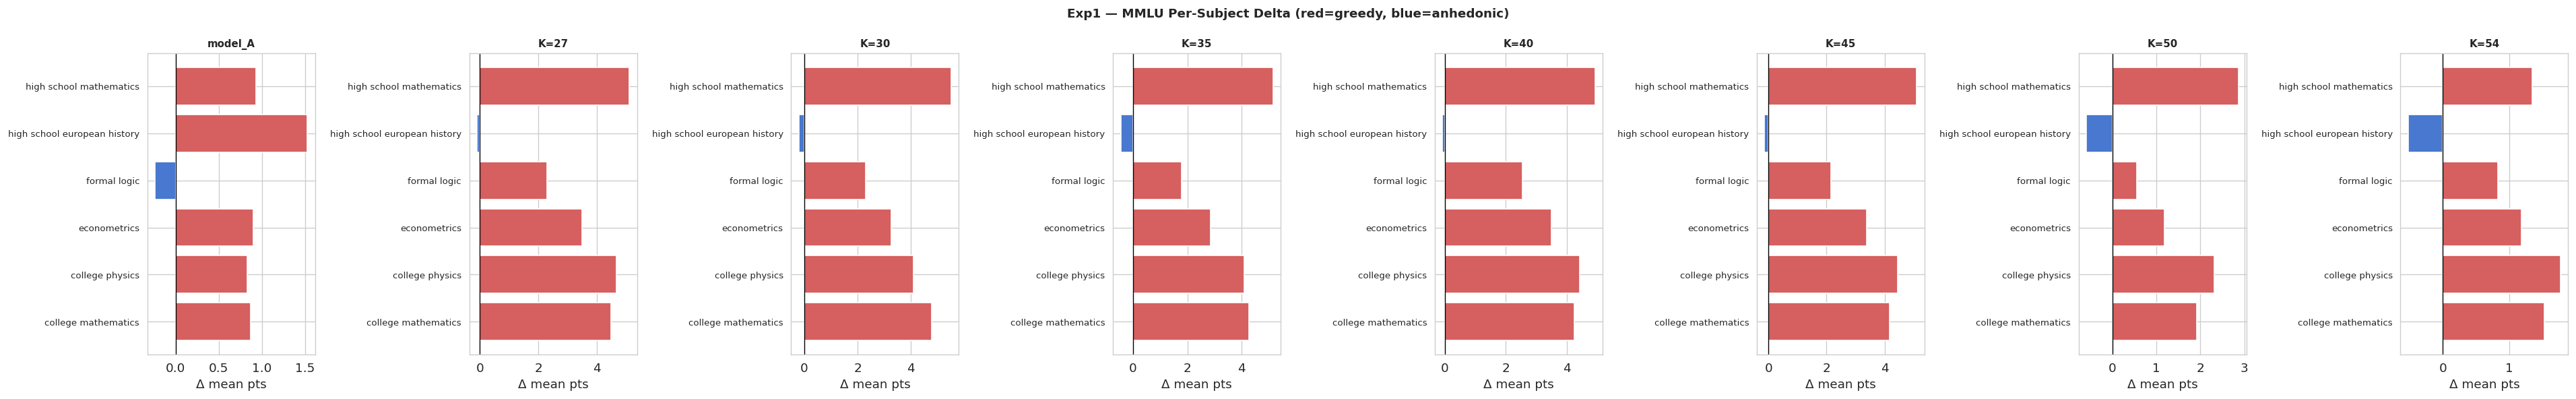

In [13]:
if mmlu_all.empty:
    print('No MMLU data yet.')
else:
    tiers_plot = [t for t in ALL_TIERS if t in mmlu_all['tier'].values]
    baseline_per_subj = mmlu_all[mmlu_all['tier']=='baseline'].set_index('subject')['mean_att_pts']

    fig, axes = plt.subplots(1, len(tiers_plot)-1,
                              figsize=(4*(len(tiers_plot)-1), 5))
    if len(tiers_plot) == 2:
        axes = [axes]

    for ax, tier in zip(axes, [t for t in tiers_plot if t != 'baseline']):
        tier_vals = mmlu_all[mmlu_all['tier']==tier].set_index('subject')['mean_att_pts']
        subjects  = sorted(tier_vals.index)
        deltas    = [tier_vals[s] - baseline_per_subj[s] for s in subjects]
        colors    = ['#D65F5F' if d > 0 else '#4878CF' for d in deltas]
        y = np.arange(len(subjects))
        ax.barh(y, deltas, color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_yticks(y)
        ax.set_yticklabels([s.replace('_',' ') for s in subjects], fontsize=8)
        ax.set_xlabel('Δ mean pts')
        ax.set_title(tier.replace('master_k','K='), fontweight='bold', fontsize=9)

    fig.suptitle('Exp1 — MMLU Per-Subject Delta (red=greedy, blue=anhedonic)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('exp1_mmlu_subjects.png', bbox_inches='tight')
    plt.show()

## 6 — Summary table

In [14]:
print(f"{'Tier':<15} {'Neurons':>8}  {'ASDiv pts':>10}  {'ΔASD':>6}  {'Orig pts':>9}  {'ΔOrig':>6}  {'MMLU pts':>9}  {'ΔMLU':>6}")
print('-'*80)

mmlu_base = mmlu_all[mmlu_all['tier']=='baseline']['mean_att_pts'].mean() if not mmlu_all.empty else None

asd_base  = asdiv_sum[asdiv_sum['tier']=='baseline']['mean_att_pts'].values[0]
orig_base = origin_sum[origin_sum['tier']=='baseline']['mean_att_pts'].values[0]

for tier in ALL_TIERS:
    n    = NEURON_COUNTS.get(tier, 0)
    asd  = asdiv_sum[asdiv_sum['tier']==tier]['mean_att_pts'].values
    orig = origin_sum[origin_sum['tier']==tier]['mean_att_pts'].values
    mmlu = mmlu_all[mmlu_all['tier']==tier]['mean_att_pts'].mean() if not mmlu_all.empty else None

    asd_v  = asd[0]  if len(asd)  else float('nan')
    orig_v = orig[0] if len(orig) else float('nan')
    mmlu_v = mmlu    if mmlu is not None else float('nan')

    d_asd  = asd_v  - asd_base
    d_orig = orig_v - orig_base
    d_mmlu = mmlu_v - mmlu_base if mmlu_base else float('nan')

    flag_asd  = '▲' if d_asd  > 0.5 else ('▼' if d_asd  < -0.5 else '–')
    flag_orig = '▲' if d_orig > 0.5 else ('▼' if d_orig < -0.5 else '–')
    flag_mmlu = '▲' if d_mmlu > 0.5 else ('▼' if d_mmlu < -0.5 else '–')

    print(f"{tier:<15} {n:>8}  {asd_v:>10.2f}  {d_asd:>+5.2f}{flag_asd}  "
          f"{orig_v:>9.2f}  {d_orig:>+5.2f}{flag_orig}  "
          f"{mmlu_v:>9.2f}  {d_mmlu:>+5.2f}{flag_mmlu}")

print()
print('▲ = greedy (Δ > 0.5)   ▼ = anhedonic (Δ < -0.5)   – = no effect')
print('Note: master core neurons are in L8-14 — ablating these makes model MORE greedy.')
print('This confirms L8-14 is a reward SUPPRESSION circuit, not a reward DRIVING circuit.')

Tier             Neurons   ASDiv pts    ΔASD   Orig pts   ΔOrig   MMLU pts    ΔMLU
--------------------------------------------------------------------------------
baseline               0       31.18  +0.00–      37.61  +0.00–      27.16  +0.00–
model_A             1363       31.61  +0.43–      35.38  -2.23▼      27.96  +0.80▲
master_k27           304       33.06  +1.88▲      38.14  +0.53▲      30.48  +3.32▲
master_k30           287       33.41  +2.23▲      38.22  +0.61▲      30.45  +3.28▲
master_k35           263       33.02  +1.84▲      38.28  +0.67▲      30.11  +2.95▲
master_k40           233       33.20  +2.02▲      38.10  +0.49–      30.42  +3.25▲
master_k45           181       32.73  +1.55▲      38.15  +0.54▲      30.35  +3.19▲
master_k50           107       31.94  +0.76▲      38.12  +0.51▲      28.54  +1.38▲
master_k54            29       32.01  +0.83▲      38.26  +0.65▲      28.18  +1.02▲

▲ = greedy (Δ > 0.5)   ▼ = anhedonic (Δ < -0.5)   – = no effect
Note: master core neuron